In [19]:
import pandas as pd
data = pd.read_csv('/home/rajs11/I_CODE/26/ML/Day4 (Gradient Descent)/Study_Hours.csv')


In [50]:

data.columns = ['hours','score']
data

,hours,score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7
5,18.0,78.8
6,19.2,77.1
7,22.2,90.8
8,25.2,99.0
9,17.4,84.6


In [51]:
import numpy as np
def model_exam_score(hours,w,b):
    # model_score = []
    pred = np.zeros(len(hours))
    for i in range(len(hours)):
        pred[i] = hours.iloc[i]*w+b
        # model_score.append(curr)
    return pred


In [52]:
actual_hours = data['hours']
actual_score = data['score']
model_score = model_exam_score(actual_hours,100,100)
model_score

array([ 490., 1060.,  550., 1240., 1540., 1900., 2020., 2320., 2620.,
       1840., 2230., 2710., 3100., 2830., 2200., 1870.,  670., 1390.,
       1840., 2230.,  490.,  910., 1540.,  400., 1060.,  610., 1060.,
       1660., 1870., 2050., 2440., 2620., 1990.])

In [53]:
def cost_function(actual_score,model_score):
    cost = 0
    initital = 1/(2*len(actual_score))
    for i in range(len(actual_score)):
        cost = cost + (model_score[i]-actual_score[i])**2
    cost = initital * cost

    return cost
    
    



#J(w,b) = (1/2m)sigma i=1 to m (y^i - yi)**2

In [57]:
def derivation_for_w_b(w,b,alpha,model_score,actual_score,actual_hours):
    wt = 0
    bi = 0
    initial = (1/len(actual_hours))
    for i in range(len(actual_hours)):
        wt = wt + (model_score[i]-actual_score.iloc[i])*actual_hours.iloc[i]
        bi = bi +  (model_score[i]-actual_score.iloc[i])
    wt = initial*wt
    bi = bi *initial
    wt = w - wt*alpha
    bi = b - bi*alpha
    cost = cost_function(actual_score,model_exam_score(actual_hours,wt,bi))
    
    return wt,bi,cost

In [72]:
w=0
b=0
model_score = model_exam_score(actual_hours,w,b)
for i in range(10000):
    w,b,cost=derivation_for_w_b(w,b,0.001,model_score,actual_score,actual_hours)
    model_score = model_exam_score(actual_hours,w,b)
    
for i in range(len(model_score)):
    print(model_score[i],"   ",actual_score[i])



42.429177351687045     40.0
57.34499514522943     57.1
43.99926343521783     42.7
62.055253395821765     65.1
69.90568381347566     78.7
79.32620031466031     78.8
82.46637248172186     77.1
90.31680289937574     90.8
98.16723331702963     99.0
77.75611423112954     84.6
87.9616737740796     92.4
100.5223624423258     95.9
110.72792198527586     92.0
103.66253460938736     100.0
87.17663073231421     86.6
78.54115727289492     97.0
47.13943560227938     57.2
65.9804686046487     74.7
77.75611423112954     64.9
87.9616737740796     84.7
42.429177351687045     49.0
53.41977993640249     58.5
69.90568381347566     76.5
40.074048226390886     42.2
57.34499514522943     51.2
45.5693495187486     42.4
57.34499514522943     64.8
73.0458559805372     79.5
78.54115727289492     79.1
83.25141552348725     82.4
93.45697506643731     91.5
98.16723331702963     96.2
81.68132943995647     89.6


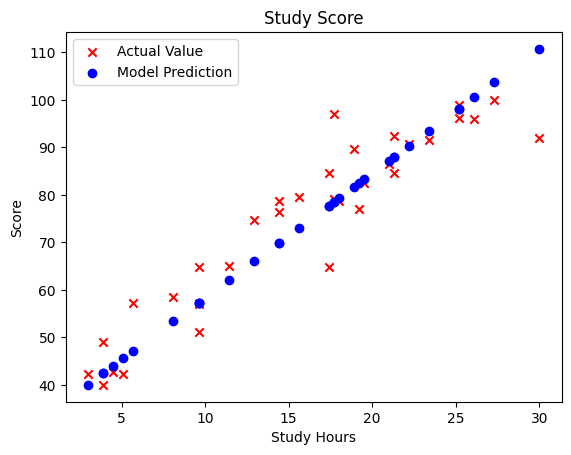

In [73]:
import matplotlib.pyplot as plt

plt.scatter(actual_hours,actual_score,marker='x',c='r',label='Actual Value')   
plt.title("Study Score")
plt.ylabel('Score')
plt.xlabel('Study Hours')
# plt.show()
plt.scatter(actual_hours,model_score,marker='o',c='b',label='Model Prediction')   
# plt.title("Study Score")
plt.legend()
# plt.ylabel('Score')
plt.xlabel('Study Hours')
plt.show()

